# A-GHOST for gFEX: cross BX MET Anomaly Detection Algorithm

This notebook trains a convolutional autoencoder to detect anomalous MET patterns across consecutive bunch crossings (BX−1, BX, BX+1). The model learns to reconstruct typical cross-BX correlations in digitized gFEX MET data, events with unusually high reconstruction error are flagged as anomalous candidates.

**Input features (per BX):** `mhxDigi`, `mhyDigi` (hard MET x/y), `msxDigi`, `msyDigi` (soft MET x/y), `metxDigi`, `metyDigi`, `metDigi` (total MET magnitude), `sumEtDigi`

**Data:** EnhancedBias dataset — a minimally-biased reference sample used to model the nominal BX activity distribution. Currently using pp data, will need to migrate to using heavy ion data at some point.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

## Imports

In [5]:
from pathlib import Path
import os
p = Path("/workspace/samples/EnhancedBias_run00500306_gFEX_digitzedMET.parquet")

print("exists:", p.exists())
print("is_file:", p.is_file())
print("is_symlink:", p.is_symlink())
print("lexists:", os.path.lexists(p))
print("realpath:", os.path.realpath(p))

exists: True
is_file: True
is_symlink: True
lexists: True
realpath: /eos/home-i03/m/mlarson/AGHOST_gFEX/EnhancedBias_run00500306_gFEX_digitzedMET.parquet


## 1. Verify Data File

Check that the input parquet file is accessible via its workspace symlink and resolve its real path on EOS.

In [11]:

file_path = "/workspace/samples/EnhancedBias_run00500306_gFEX_digitzedMET.parquet"

df = pd.read_parquet(file_path)

## 2. Load Data

Read the EnhancedBias run parquet file into a pandas DataFrame. Each row is one gFEX readout event containing digitized MET components and event metadata.

In [12]:
df.head(20)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi,eventWeight,eventBiasedFlag
0,0,0,33,41,18,-9,20,0,12.000,False
1,0,0,15,7,14,9,16,0,5.000,False
2,0,0,35,-144,24,-28,36,0,453438.000,True
3,0,0,162,-255,57,-93,109,0,13740.600,False
4,0,0,56,2,-7,13,14,0,453438.000,True
5,0,0,-54,1,-19,-2,19,0,5.000,False
6,0,0,19,-3,0,-14,14,0,5.000,False
7,0,0,-67,36,-23,11,25,0,493448.000,True
8,-74,-2,114,-137,-46,-52,69,72,54962.200,False
9,0,0,143,-204,37,-58,68,0,453438.000,True


In [13]:
df_features = df

df_features.head(20)

,mhxDigi,mhyDigi,msxDigi,msyDigi,metxDigi,metyDigi,metDigi,sumEtDigi,eventWeight,eventBiasedFlag
0,0,0,33,41,18,-9,20,0,12.000,False
1,0,0,15,7,14,9,16,0,5.000,False
2,0,0,35,-144,24,-28,36,0,453438.000,True
3,0,0,162,-255,57,-93,109,0,13740.600,False
4,0,0,56,2,-7,13,14,0,453438.000,True
5,0,0,-54,1,-19,-2,19,0,5.000,False
6,0,0,19,-3,0,-14,14,0,5.000,False
7,0,0,-67,36,-23,11,25,0,493448.000,True
8,-74,-2,114,-137,-46,-52,69,72,54962.200,False
9,0,0,143,-204,37,-58,68,0,453438.000,True


## 3. Build Cross-BX Context Windows

For each event, concatenate features from the preceding BX (BX−1) and following BX (BX+1) alongside the current BX. This creates a sliding 3-BX window that captures temporal MET correlations across bunch crossings. The first and last rows are dropped since they lack a valid neighbor on one side.

In [14]:
# previous and next rows
df_prev = df_features.shift(1)
df_next = df_features.shift(-1)

# rename columns to keep them distinct
df_prev.columns = [f"{c}_prev" for c in df_prev.columns]
df_next.columns = [f"{c}_next" for c in df_next.columns]

# combine
df_context = pd.concat([df_prev, df_features, df_next], axis=1)

# drop first and last rows (invalid due to shift)
df_context = df_context.iloc[1:-1].reset_index(drop=True)

df_context.head(20)

,mhxDigi_prev,mhyDigi_prev,msxDigi_prev,msyDigi_prev,metxDigi_prev,metyDigi_prev,metDigi_prev,sumEtDigi_prev,eventWeight_prev,eventBiasedFlag_prev,...,mhxDigi_next,mhyDigi_next,msxDigi_next,msyDigi_next,metxDigi_next,metyDigi_next,metDigi_next,sumEtDigi_next,eventWeight_next,eventBiasedFlag_next
0,0.0,0.0,33.0,41.0,18.0,-9.0,20.0,0.0,12.000,False,...,0.0,0.0,35.0,-144.0,24.0,-28.0,36.0,0.0,453438.000,True
1,0.0,0.0,15.0,7.0,14.0,9.0,16.0,0.0,5.000,False,...,0.0,0.0,162.0,-255.0,57.0,-93.0,109.0,0.0,13740.600,False
2,0.0,0.0,35.0,-144.0,24.0,-28.0,36.0,0.0,453438.000,True,...,0.0,0.0,56.0,2.0,-7.0,13.0,14.0,0.0,453438.000,True
3,0.0,0.0,162.0,-255.0,57.0,-93.0,109.0,0.0,13740.600,False,...,0.0,0.0,-54.0,1.0,-19.0,-2.0,19.0,0.0,5.000,False
4,0.0,0.0,56.0,2.0,-7.0,13.0,14.0,0.0,453438.000,True,...,0.0,0.0,19.0,-3.0,0.0,-14.0,14.0,0.0,5.000,False
5,0.0,0.0,-54.0,1.0,-19.0,-2.0,19.0,0.0,5.000,False,...,0.0,0.0,-67.0,36.0,-23.0,11.0,25.0,0.0,493448.000,True
6,0.0,0.0,19.0,-3.0,0.0,-14.0,14.0,0.0,5.000,False,...,-74.0,-2.0,114.0,-137.0,-46.0,-52.0,69.0,72.0,54962.200,False
7,0.0,0.0,-67.0,36.0,-23.0,11.0,25.0,0.0,493448.000,True,...,0.0,0.0,143.0,-204.0,37.0,-58.0,68.0,0.0,453438.000,True
8,-74.0,-2.0,114.0,-137.0,-46.0,-52.0,69.0,72.0,54962.200,False,...,0.0,0.0,10.0,57.0,7.0,37.0,37.0,0.0,12.000,False
9,0.0,0.0,143.0,-204.0,37.0,-58.0,68.0,0.0,453438.000,True,...,0.0,0.0,65.0,181.0,16.0,44.0,46.0,0.0,453438.000,True


## 4. Reshape to 3D Tensor

Reorder columns into [BX−1 | BX | BX+1] order and reshape the flat feature matrix into shape `(N, 3, 8)` — N samples, 3 time steps, 8 features per BX. This format is the direct input to the Conv1D autoencoder.

In [15]:
base_features = [
    "mhxDigi", "mhyDigi", "msxDigi", "msyDigi",
    "metxDigi", "metyDigi", "metDigi", "sumEtDigi"
]

ordered_cols = (
    [f"{f}_prev" for f in base_features] +
    base_features +
    [f"{f}_next" for f in base_features]
)

X = df_context[ordered_cols].to_numpy(dtype="float32")
X = X.reshape(-1, 3, 8)

print(X.shape)  # should be (n_samples, 3, 8)

(1029076, 3, 8)


## 5. Train / Test Split

Split the full dataset 80/20 into training and test sets with a fixed random seed for reproducibility. The autoencoder is trained on `X_train` and its performance is monitored on `X_test`.

In [16]:
train_df, test_df = train_test_split(
    X,
    test_size=0.2,   # 20% test
    random_state=43  # reproducibility
)
display(train_df)
display(test_df)

array([[[   0.,    0.,   -1., ...,   29.,   29.,    0.],
        [   0.,    0.,   35., ...,   13.,   15.,    0.],
        [   5.,   -6.,   -2., ...,   37.,   37.,    0.]],

       [[   0.,    0.,  -99., ...,   -4.,   48.,    0.],
        [   0.,    0.,  -84., ...,  -28.,   28.,    0.],
        [  -4., -101.,   12., ...,  -69.,   69.,   98.]],

       [[  42.,   19.,   31., ...,   20.,   55.,  220.],
        [  32.,  -78., -153., ...,  -69.,   74.,  474.],
        [ -73.,  -56.,   54., ...,  -21.,   75.,  208.]],

       ...,

       [[   0.,    0., -130., ...,    8.,   46.,    0.],
        [   0.,    0.,   -4., ...,   22.,   38.,    0.],
        [   0.,   81.,  -70., ...,   74.,   76.,   79.]],

       [[   0.,    0., -203., ...,   11.,   67.,    0.],
        [   0.,    0.,  -75., ...,  -29.,   40.,    0.],
        [   0.,    0.,   18., ...,   30.,   35.,    0.]],

       [[   0.,    0.,   70., ...,  -30.,   34.,    0.],
        [   0.,    0.,  -16., ...,   24.,   28.,    0.],
        

array([[[   0.,    0.,   36., ...,   19.,   20.,    0.],
        [   0.,    0.,  -75., ...,   -8.,   20.,    0.],
        [   0.,    0.,  -41., ...,   -7.,   15.,    0.]],

       [[ -83.,  -82.,   -3., ...,  -67.,  126.,  113.],
        [  92.,   99.,   21., ...,   94.,  119.,  485.],
        [   0.,    0.,  -19., ...,  -14.,   17.,    0.]],

       [[ -41., -175.,  115., ..., -166.,  167., 1301.],
        [  70.,  -76., -102., ...,  -63.,   87.,  280.],
        [   0.,    0.,  111., ...,  -41.,   81.,    0.]],

       ...,

       [[  30.,   35.,  151., ...,   36.,   93.,  576.],
        [  14.,  -23.,  -42., ...,  -84.,   84.,   26.],
        [-135.,  133.,  -12., ...,   95.,  150.,  832.]],

       [[   0.,    0.,   53., ...,  -58.,   59.,    0.],
        [ -97.,  -90.,   94., ...,  -42.,   76.,  129.],
        [   0.,    0.,   78., ...,   27.,   27.,    0.]],

       [[  -9.,  -33.,  -72., ..., -108.,  108.,   51.],
        [   0.,    0.,   71., ...,   40.,   44.,    0.],
        

## 6. Feature Normalization

Fit a `StandardScaler` on the training data (flattened to 2D across all BX positions) and apply it to both sets. Each of the 8 digitized features is scaled to zero mean and unit variance, which improves gradient flow during training. The scaler is fit **only** on training data to avoid leakage.

In [17]:
# train_df and test_df are assumed to already be numpy arrays of shape (n_samples, 3, 8)

scaler = StandardScaler()

n_train = train_df.shape[0]
n_test = test_df.shape[0]

# collapse samples and BX axes together: (n_samples*3, 8)
train_2d = train_df.reshape(-1, train_df.shape[-1])
test_2d  = test_df.reshape(-1, test_df.shape[-1])

# fit only on training data
train_2d_scaled = scaler.fit_transform(train_2d)
test_2d_scaled  = scaler.transform(test_2d)

# reshape back to (n_samples, 3, 8)
X_train = train_2d_scaled.reshape(n_train, 3, 8)
X_test  = test_2d_scaled.reshape(n_test, 3, 8)

print(X_train.shape)
print(X_test.shape)

(823260, 3, 8)
(205816, 3, 8)


## 7. Define Convolutional Autoencoder

Build a Conv1D autoencoder that takes BX triplets of shape `(3, 8)` as input. The encoder uses two Conv1D layers to extract cross-BX MET patterns, then compresses them to a 16-dimensional latent vector. The decoder mirrors this structure to reconstruct the original triplet.

After training, the per-event reconstruction error (MSE) serves as the anomaly score — nominal BX patterns are reconstructed accurately, while unusual cross-BX MET correlations (e.g. large correlated MET swings across BXs) produce elevated error and are flagged as anomaly candidates.

In [18]:
n_bx = 3
n_feat_per_bx = 8
latent_dim = 16

inputs = keras.Input(shape=(n_bx, n_feat_per_bx))

# Encoder
x = layers.Conv1D(64, kernel_size=2, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)

x = layers.Conv1D(128, kernel_size=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)

# Decoder
x = layers.Dense(n_bx * 128, activation="relu")(latent)
x = layers.Reshape((n_bx, 128))(x)

x = layers.Conv1D(64, kernel_size=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

outputs = layers.Conv1D(n_feat_per_bx, kernel_size=2, padding="same", activation="linear")(x)

autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
encoder = keras.Model(inputs, latent, name="encoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

2026-04-17 12:39:26.443385: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-04-17 12:39:26.452495: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-04-17 12:39:26.611958: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 93005 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:a1:00.0, compute capability: 9.0


Model: "conv_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3, 8)]            0         
                                                                 
 conv1d (Conv1D)             (None, 3, 64)             1088      
                                                                 
 batch_normalization (Batch  (None, 3, 64)             256       
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 3, 128)            16512     
                                                                 
 batch_normalization_1 (Bat  (None, 3, 128)            512       
 chNormalization)                                                
                                                                 
 flatten (Flatten)           (None, 384)          

## 8. Visualize Model Architecture

Generate an annotated layer diagram of the autoencoder with tensor shapes at each stage.

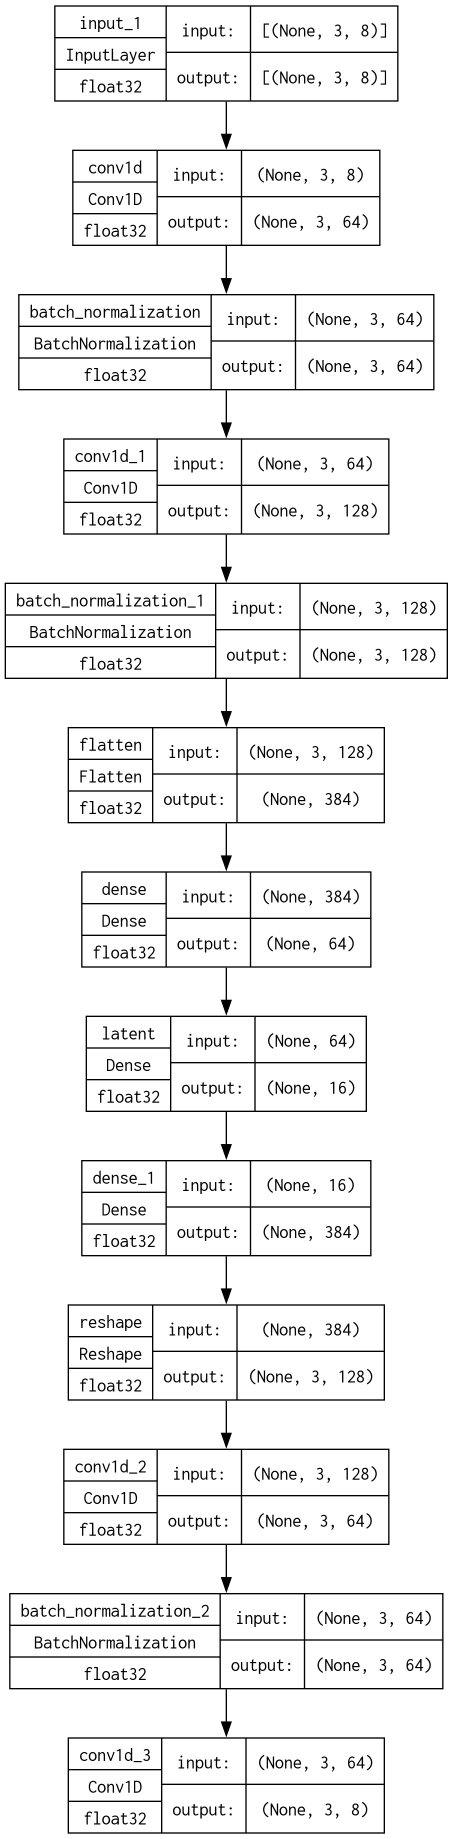

In [20]:
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    to_file="autoencoder.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True
)

## 9. Train the Autoencoder

Train the model to reconstruct its own input using MSE loss over 25 epochs. The model learns the distribution of normal cross-BX MET patterns from the EnhancedBias sample. Once trained, events with reconstruction error well above the typical range are anomaly candidates — they contain cross-BX MET structure the model was unable to reproduce.

In [21]:
# ----------------------------
# 3. Train
# ----------------------------
history = autoencoder.fit(
    X_train,
    X_train,   # target is the input itself
    validation_data=(X_test, X_test),
    epochs=25,
    batch_size=256,
    shuffle=True,
    verbose=1
)

2026-04-17 12:39:48.570167: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-17 12:39:48.635007: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-17 12:39:48.758893: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-17 12:39:50.479757: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fe5bbc57cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-17 12:39:50.479804: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA H100 NVL, Compute Capability 9.0
2026-04-17 12:39:50.483465: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776422390.563013    3294 device_compiler.h:186] C

3216/3216 [==============================] - 28s 7ms/step - loss: 0.0535 - val_loss: 0.0321


In [ ]:
import tf2onnx
import onnx

# Convert and save
input_signature = [tf.TensorSpec(shape=(None, 3, 8), dtype=tf.float32, name="input")]
onnx_model, _ = tf2onnx.convert.from_keras(autoencoder, input_signature=input_signature)
onnx.save(onnx_model, "cross_BX_gFEXMET_autoencoder.onnx")


2026-04-17 12:44:06.234977: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-17 12:44:06.235115: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-17 12:44:06.239536: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-04-17 12:44:06.241929: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 93005 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:a1:00.0, compute capability: 9.0
2026-04-17 12:44:06.293899: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take